In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import Bio
import Bio.Seq

## Import Dataset

In [2]:
df = pd.read_pickle("data/beta_activity.pkl")
df.head()

,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,17456,3
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,13670,3
2,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,11180,3
3,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,10159,3
4,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,3976,3


In [3]:
df.response.value_counts()

0    694
1    192
2     54
3     20
Name: response, dtype: int64

In [4]:
# number of sequences
Nseq = len(df)
Nseq

960

In [5]:
# WildType Sequence
WT_DNA = 'ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAGCACGTGCAGAACATATGACCATTGCAGCAGCAATTCATGCACTGGATGCAGATGAAGCAGATGCAATTGTTATGGATATTGTTCCGGATGGTGAACGTGATGCATGGTGGGATGATGAAGGTTTTAGCAGCAGCCCGTTTACCAAAGATGCACATCATGCAGGAGTTGTTGCAACCAGCGTTACCCTGGGTCAGCTGCAGCGTGAACAGGGTGATAAACTGGTTAGCAAAGCAGCAGAATATTTTGGTATTGCCTGCCGTGTTAATGATGGTCTGCGTACCACCCGTTTTGTTCGTCTGTTTAGTGATGCCCTGGATGCCAAACCGCTGACCATTGGTCATGATTATGAAGTTGAATTTCTGCTGGCAACCCGTCGTGTTTATGAACCGTTTGAAGCACCGTTTAACTTTGCACCGCATTGTGGCGATGTTAGCTATGGTCGTGATACCGTTAATTGGCCTCTGAAACATAGCTTTCCGCGTCAGCTGGGTGGTTTTCTGACCATTCAGGGTGCAGATAATGATGCCGGTATGGTTATGTGGGATAATCGTCCGGAAAGCCGTGCAGCGCTGGATGAAATGCATGCAGAATATCGTGAAACCGGTGCAATTGCCGCACTGGAACGTGCAGCCAAAATCATGCTGAAACCGCAGCCTGGCCAGCTGACACTGTTTCAGAGCAAAAATCTGCATGCCATTGAACGTTGTACCAGCACCCGTCGTACCATGGGTCTGTTTCTGATTCATACCGAAGATGGTTGGCGTATGTTTGATTGA'
WT = Bio.Seq.Seq(WT_DNA).translate()
WT

Seq('MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDGERDAWWDD...FD*', HasStopCodon(ExtendedIUPACProtein(), '*'))

In [6]:
# Length of a sequence
N = len(df.iloc[0].sequence)
N

274

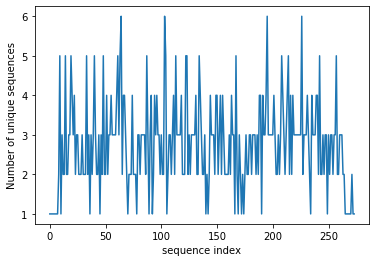

In [7]:
# Number of unique mutations at each index
num_unique = np.array([len(df.sequence.str.get(i).unique()) for i in range(N)])
plt.plot(num_unique)
plt.xlabel("sequence index")
plt.ylabel("Number of unique sequences");

In [8]:
len(df.sequence.unique())

900

In [9]:
len(df)

960

In [10]:
# location of the first stop sequence
df["first_stop"] = df.sequence.str.find("*")
print((df.first_stop != (N-1)).sum())
# print out wherever we have a stop in the middle
df[df.first_stop != (N-1)]

43


,sequence,count,response,first_stop
15,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,1631,3,122
18,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,1263,3,122
11,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,101,0,84
26,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,38,0,214
30,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,36,0,84
40,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,32,0,195
92,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,22,0,91
101,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,21,0,212
133,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,17,0,167
146,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,16,0,170


In [11]:
df[df.sequence == WT]

,sequence,count,response,first_stop
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,17456,3,273
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,29398,2,273
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,1124,1,273
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,781,0,273


In [12]:
df_nostop = df[df.first_stop == (len(WT) -1)].drop(columns=['first_stop'])
df_nostop.head()

,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,17456,3
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,13670,3
2,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,11180,3
3,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,10159,3
4,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,3976,3


In [13]:
# Replace non-unique sequences with their response category with the highest count
df_unique = df_nostop.sort_values('count', ascending=False).groupby('sequence').head(1).reset_index(drop=True)
df_unique.head()

,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,29398,2
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,20885,2
2,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,13670,3
3,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,10801,2
4,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,6016,2


In [14]:
df_unique[["sequence", "response"]].groupby("response").count()

,sequence
response,
0,615
1,178
2,53
3,11


In [15]:
# Where is WT in this dataframe
# It should be at the top
df_unique[df_unique.sequence==WT]

,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,29398,2


In [16]:
# drop the start and stop codons
df_unique.sequence = df_unique.sequence.str.slice(1, (len(WT)-1))

## Ordinal regression

In [17]:
from sklearn.preprocessing import OneHotEncoder # to create the design matrix
from sklearn.linear_model import Ridge, LinearRegression, LogisticRegression
import mord
from mord import LogisticAT

In [18]:
design_cols = df_unique.sequence.apply(lambda x: pd.Series(list(x)))

# one hot encode the design columns to get a design matrix
enc = OneHotEncoder(
    drop=None, # don't drop columns 
    sparse=False ) # setting to False for now
X = enc.fit_transform(design_cols)
print(X.shape)
X

(857, 723)


array([[1., 1., 1., ..., 1., 0., 1.],
       [1., 1., 1., ..., 1., 0., 1.],
       [1., 1., 1., ..., 1., 0., 1.],
       ...,
       [1., 1., 1., ..., 1., 0., 1.],
       [1., 1., 1., ..., 1., 0., 1.],
       [1., 1., 1., ..., 1., 0., 1.]])

In [19]:
enc.get_feature_names().size

723

In [20]:
y = df_unique.response.to_numpy()

In [21]:
# Try out model with alpha = 1.0
model = mord.LogisticAT(alpha=1.0)
model._estimator_type = "classifier" # for CV to use Stratified Kfold
model.fit(X, y)
model.score(X, y)

-0.13885647607934656

In [22]:
#model = Ridge(alpha=1.0)
#model.fit(X,y)
#model.score(X, y)

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import GridSearchCV

In [24]:
pipe = Pipeline([('vt', VarianceThreshold()), ('scaler', StandardScaler()), ('model', model)])

In [25]:
alphas = np.logspace(-6, 2, 10) # search space for regularization params
grid_cv = GridSearchCV(estimator=pipe, param_grid=dict(model__alpha=alphas), cv=5, iid='deprecated')
grid_cv.fit(X, y)

GridSearchCV(cv=5, error_score='raise-deprecating',
             estimator=Pipeline(memory=None,
                                steps=[('vt', VarianceThreshold(threshold=0.0)),
                                       ('scaler',
                                        StandardScaler(copy=True,
                                                       with_mean=True,
                                                       with_std=True)),
                                       ('model',
                                        LogisticAT(alpha=1.0, max_iter=1000,
                                                   verbose=0))],
                                verbose=False),
             iid='deprecated', n_jobs=None,
             param_grid={'model__alpha': array([1.00000000e-06, 7.74263683e-06, 5.99484250e-05, 4.64158883e-04,
       3.59381366e-03, 2.78255940e-02, 2.15443469e-01, 1.66810054e+00,
       1.29154967e+01, 1.00000000e+02])},
             pre_dispatch='2*n_jobs', refit=True, retur

In [26]:
grid_cv.cv_results_

{'mean_fit_time': array([1.20038323, 1.19753995, 1.41502843, 1.25115852, 1.1954102 ,
        0.82229762, 0.4034739 , 0.19941778, 0.1322124 , 0.09046383]),
 'std_fit_time': array([0.0090074 , 0.00935473, 0.18089509, 0.12001855, 0.02413656,
        0.09754757, 0.07395765, 0.00760123, 0.00570599, 0.00525667]),
 'mean_score_time': array([0.00217791, 0.00204921, 0.00212803, 0.00214815, 0.00177274,
        0.00216079, 0.00178523, 0.00172629, 0.00171957, 0.00172944]),
 'std_score_time': array([8.18674903e-04, 5.66921562e-04, 4.98533411e-04, 5.29989690e-04,
        2.54639972e-05, 5.41173182e-04, 6.77085930e-05, 2.12546386e-05,
        1.65570331e-05, 2.11338403e-05]),
 'param_model__alpha': masked_array(data=[1e-06, 7.742636826811277e-06, 5.994842503189409e-05,
                    0.00046415888336127773, 0.003593813663804626,
                    0.02782559402207126, 0.21544346900318823,
                    1.6681005372000557, 12.915496650148826, 100.0],
              mask=[False, False, False

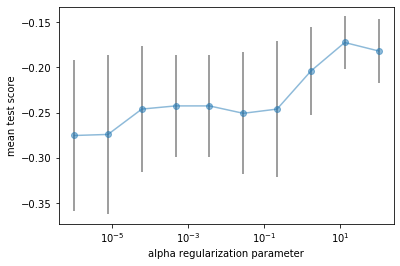

In [27]:
plt.errorbar(alphas, grid_cv.cv_results_["mean_test_score"],
             grid_cv.cv_results_["std_test_score"], fmt='-o', ecolor="black", alpha=0.5)
plt.xscale('log')
plt.xlabel("alpha regularization parameter")
plt.ylabel("mean test score");

In [28]:
# regularization parameter picked by CV
grid_cv.best_params_

{'model__alpha': 12.915496650148826}

In [29]:
grid_cv.best_score_

-0.17269544924154026

In [30]:
best_model = grid_cv.best_estimator_['model']

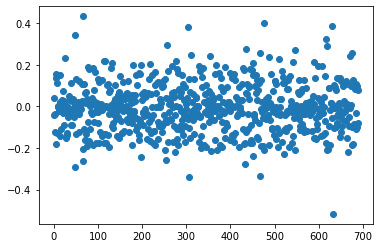

In [31]:
grid_cv.best_estimator_.fit(X, y)
best_coefs = grid_cv.best_estimator_['model'].coef_

plt.plot(best_coefs, 'o')

In [32]:
vt = grid_cv.best_estimator_.named_steps['vt']
feature_names_after_threshold = enc.get_feature_names()[vt.get_support()]

In [33]:
best_results = pd.DataFrame({'feature':feature_names_after_threshold, 'coef':best_coefs})

In [34]:
best_results.sort_values('coef', ascending=False).head(10)

,feature,coef
66,x32_K,0.434472
476,x190_S,0.400383
629,x241_K,0.388234
304,x121_I,0.380436
49,x24_T,0.343892
617,x237_Q,0.322515
256,x103_G,0.295836
619,x238_F,0.290028
434,x174_R,0.277446
545,x213_G,0.271755


In [46]:
def show_design_response(col_num):
    return pd.DataFrame({'aa':design_cols[col_num], 'response':y}).groupby(['aa', 'response']).size()
show_design_response(32)

aa  response
D   0             2
    1             1
E   0           601
    1           177
    2            53
    3            10
G   0             7
K   0             1
    3             1
V   0             4
dtype: int64

In [45]:
show_design_response(191)

aa  response
I   1             1
K   0             2
M   0           613
    1           177
    2            53
    3            11
dtype: int64

In [37]:
best_results.sort_values('coef', ascending=True).head(10)

,feature,coef
631,x241_R,-0.517272
306,x121_R,-0.340135
466,x187_I,-0.332659
47,x24_A,-0.292570
433,x174_H,-0.277446
65,x32_G,-0.260662
253,x103_A,-0.257473
198,x82_G,-0.243909
451,x181_S,-0.239142
520,x204_P,-0.228707


In [47]:
show_design_response(241)

aa  response
E   0             2
    1             1
K   0           604
    1           177
    2            53
    3            11
N   0             3
R   0             6
dtype: int64

In [39]:
show_design_response(214)

aa  response
A   0             2
    1             1
T   0           613
    1           177
    2            53
    3            11
dtype: int64

In [40]:
pd.set_option('display.max_rows', 1000)
best_results

,feature,coef
0,x7_L,4.245764e-02
1,x7_P,-4.245764e-02
2,x8_I,-1.233362e-01
3,x8_K,-3.539006e-02
4,x8_M,1.553335e-01
5,x8_P,1.356307e-01
6,x8_V,-1.792635e-01
7,x10_F,1.125199e-01
8,x10_L,-1.252873e-01
9,x10_S,-8.783160e-04
